Accuracy: 0.8416666666666667
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1068
           1       0.26      0.23      0.25       132

    accuracy                           0.84      1200
   macro avg       0.58      0.58      0.58      1200
weighted avg       0.84      0.84      0.84      1200


Feature Importance:
            Feature  Importance
1      MonthlySpend    0.249630
2            Tenure    0.208683
0               Age    0.191640
4    LoginFrequency    0.189417
3    SupportTickets    0.129878
5  SubscriptionType    0.030751


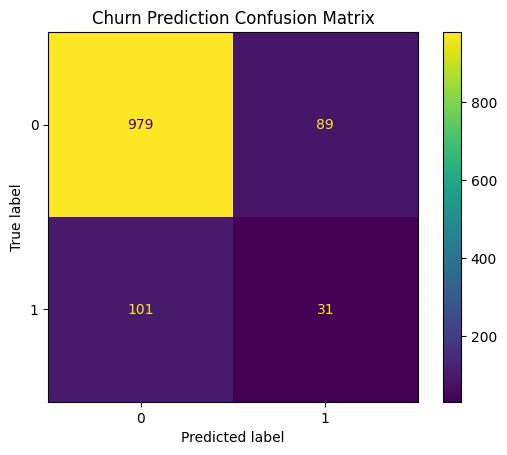

In [11]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 6000

data = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "MonthlySpend": np.random.randint(50, 500, n),
    "Tenure": np.random.randint(1, 36, n),
    "SupportTickets": np.random.randint(0, 10, n),
    "LoginFrequency": np.random.randint(1, 30, n),
    "SubscriptionType": np.random.choice([0,1], n)
})

data["Churn"] = (
    (data["Tenure"] < 6) &
    (data["SupportTickets"] > 5) &
    (data["LoginFrequency"] < 10)
).astype(int)

noise = np.random.choice([0,1], size=n, p=[0.9,0.1])
data["Churn"] = np.abs(data["Churn"] - noise)

from sklearn.model_selection import train_test_split

X = data.drop("Churn", axis=1)
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

y_pred = (y_prob > 0.2).astype(int)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Churn Prediction Confusion Matrix")
plt.show()